# Analyse Statistique — Phase 2 : NNH + 2-opt

---

> **Objectif**  
> Transformer les résultats bruts du CSV en insights visuels et statistiques exploitables.  
> Ce notebook est conçu pour être **réutilisé en Phase 5** : il suffit de charger les CSV des autres méthodes (recuit, DL) pour comparer.

---

## Table des matières
1. [Chargement & Statistiques descriptives](#1)
2. [Boxplots — Dispersion par taille](#2)
3. [Histogrammes — Distribution des coûts et des temps](#3)
4. [Évolution — Scalabilité en fonction de n](#4)
5. [Corrélations — Relations entre variables](#5)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

TAILLES   = [10, 20, 50, 100, 200]
CSV_PATH  = os.path.join('resultats', 'resultats_nnh.csv')
FIG_DIR   = os.path.join('resultats', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

PALETTE   = sns.color_palette('Blues_d', len(TAILLES))
PALETTE_N = dict(zip(TAILLES, PALETTE))

def sauvegarder(fig, nom):
    fig.savefig(os.path.join(FIG_DIR, nom), bbox_inches='tight')

print('Librairies chargees.')

Librairies chargees.


---
<a id='1'></a>
## 1. Chargement & Statistiques descriptives

On charge le CSV et on calcule pour chaque taille $n$ :
**moyenne**, **écart-type**, **variance**, **médiane**, **min**, **max**.

In [2]:
df = pd.read_csv(CSV_PATH)
df['valide'] = df['valide'].astype(str).str.strip().str.lower() == 'true'

print(f'Instances : {len(df)} lignes')
print(f'Tailles   : {sorted(df["n"].unique())}')
print(f'Valides   : {df["valide"].mean()*100:.1f}%')
df.head()

Instances : 150 lignes
Tailles   : [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]
Valides   : 100.0%


,methode,n,seed,cout,cout_initial,gain_pct,temps_total,n_vehicules,n_infaisables,valide
0,NNH+2opt,10,0,702.64,702.64,0.00,0.0001,5,0,True
1,NNH+2opt,10,1,522.34,522.34,0.00,0.0001,4,0,True
2,NNH+2opt,10,2,432.44,433.52,0.25,0.0001,3,0,True
3,NNH+2opt,10,3,457.14,457.14,0.00,0.0001,4,0,True
4,NNH+2opt,10,4,488.96,488.96,0.00,0.0001,3,0,True


In [3]:
def tableau_stats(df, variable, nom_affiche):
    tbl = df.groupby('n')[variable].agg(
        Moyenne    = 'mean',
        Ecart_type = 'std',
        Variance   = 'var',
        Mediane    = 'median',
        Min        = 'min',
        Max        = 'max',
    ).round(4)
    print(f'\n=== {nom_affiche} ===')
    display(tbl)
    return tbl

tbl_cout   = tableau_stats(df, 'cout',        'COUT TOTAL')
tbl_temps  = tableau_stats(df, 'temps_total', 'TEMPS DE CALCUL (s)')
tbl_veh    = tableau_stats(df, 'n_vehicules', 'NOMBRE DE VEHICULES')
tbl_gain   = tableau_stats(df, 'gain_pct',    'GAIN 2-OPT (%)')


=== COUT TOTAL ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,519.7223,70.7799,5009.7877,522.980,386.28,702.64
20,814.4070,95.5822,9135.9618,807.855,585.15,1011.98
50,1473.1503,123.7841,15322.5069,1490.320,1220.04,1716.15
100,2418.2090,175.6228,30843.3660,2445.715,2053.15,2814.23
200,3863.8257,155.8973,24303.9572,3862.180,3586.85,4180.17



=== TEMPS DE CALCUL (s) ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,0.0001,0.0000,0.0,0.0001,0.0001,0.0001
20,0.0003,0.0000,0.0,0.0003,0.0003,0.0004
50,0.0016,0.0002,0.0,0.0016,0.0014,0.0021
100,0.0064,0.0011,0.0,0.0060,0.0053,0.0093
200,0.0223,0.0032,0.0,0.0210,0.0196,0.0331



=== NOMBRE DE VEHICULES ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,3.4667,0.5713,0.3264,3.0,3,5
20,4.7667,0.9353,0.8747,5.0,3,7
50,8.0000,0.9097,0.8276,8.0,6,10
100,13.3667,1.3257,1.7575,13.5,11,16
200,21.9333,1.4606,2.1333,22.0,19,25



=== GAIN 2-OPT (%) ===


,Moyenne,Ecart_type,Variance,Mediane,Min,Max
n,,,,,,
10,0.0637,0.1943,0.0377,0.000,0.00,0.93
20,0.6397,1.3781,1.8990,0.000,0.00,6.45
50,0.9597,0.9712,0.9433,0.740,0.00,4.25
100,0.8690,0.6642,0.4412,0.850,0.00,2.98
200,0.7390,0.4740,0.2247,0.605,0.12,1.97


---
<a id='2'></a>
## 2. Boxplots — Dispersion par taille

Les boîtes à moustaches montrent :
- La **médiane** (ligne rouge)
- Le **premier et troisième quartile** (bornes de la boîte = 50% des données)
- Les **valeurs aberrantes** (points isolés au-delà des moustaches)

Chaque métrique a son propre graphe pour une meilleure lisibilité.

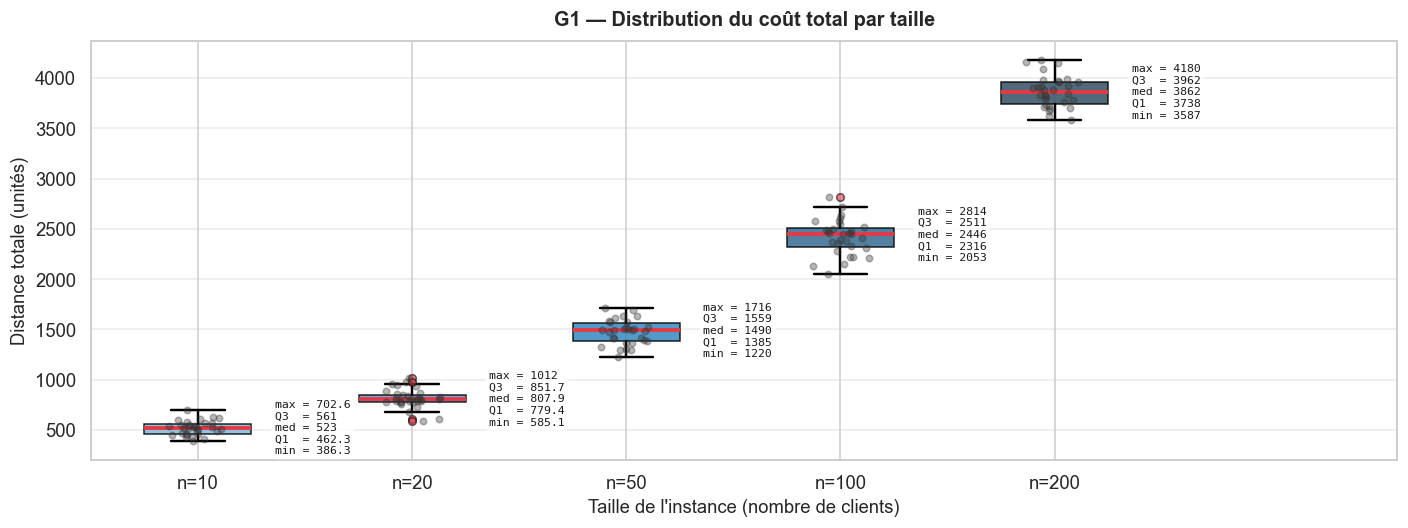

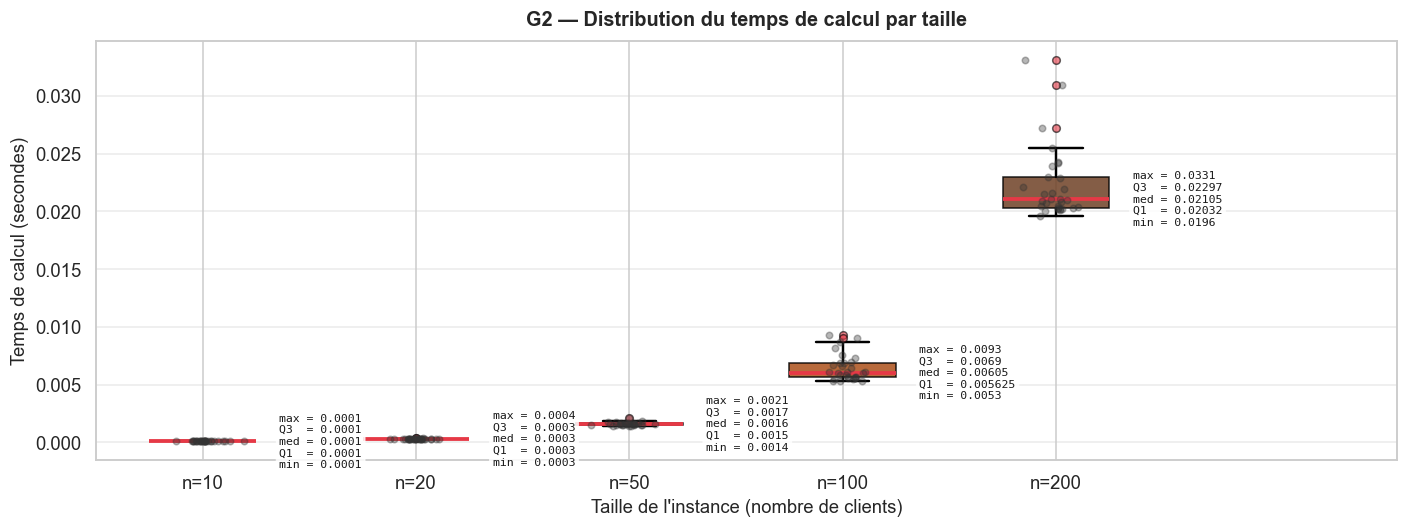

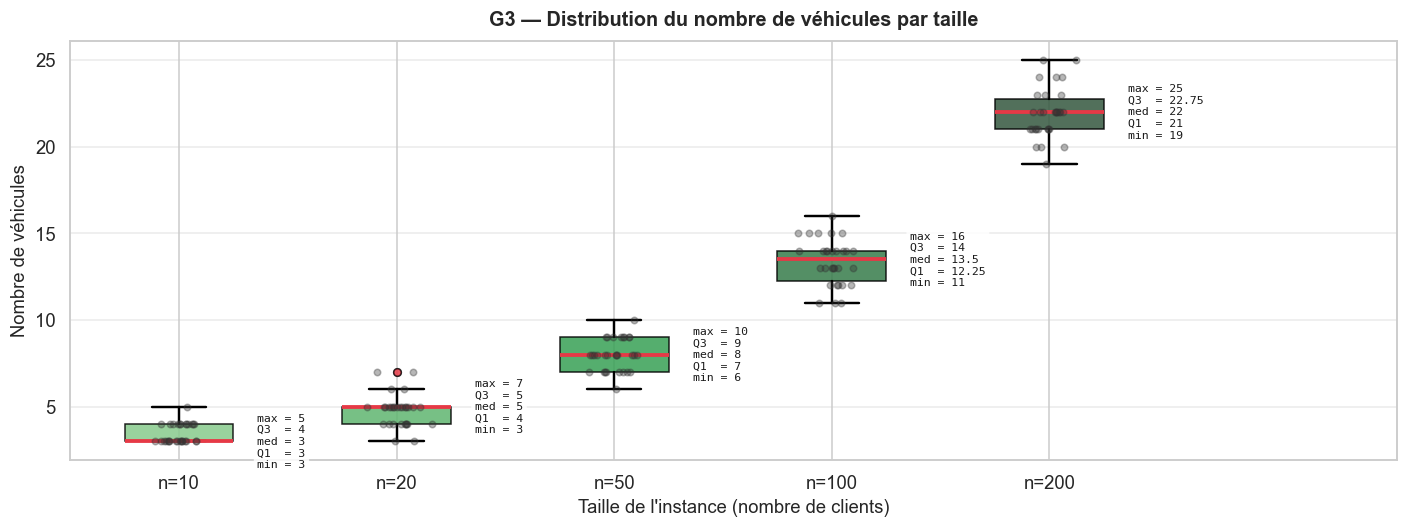

In [4]:
def boxplot_metrique(df, variable, ylabel, titre, fname, couleur):
    fig, ax = plt.subplots(figsize=(13, 5))

    data = [df[df['n'] == n][variable].values for n in TAILLES]
    bp   = ax.boxplot(
        data,
        tick_labels  = [f'n={n}' for n in TAILLES],
        patch_artist = True,
        medianprops  = {'color': '#e63946', 'linewidth': 2.5},
        whiskerprops = {'linewidth': 1.6},
        capprops     = {'linewidth': 1.6},
        flierprops   = {'marker': 'o', 'markersize': 5,
                        'markerfacecolor': '#e63946', 'alpha': 0.6},
    )
    shades = sns.color_palette(couleur, len(TAILLES))
    for patch, col in zip(bp['boxes'], shades):
        patch.set_facecolor(col)
        patch.set_alpha(0.85)

    # Points individuels (jitter)
    for i, (n, col) in enumerate(zip(TAILLES, shades)):
        y = df[df['n'] == n][variable].values
        x = np.random.normal(i + 1, 0.06, size=len(y))
        ax.scatter(x, y, alpha=0.35, s=18, color='#333333', zorder=3)

    # Annotations statistiques (min / Q1 / médiane / Q3 / max) à droite de chaque boîte
    for i, n in enumerate(TAILLES):
        y   = df[df['n'] == n][variable].values
        mn  = y.min()
        q1  = np.percentile(y, 25)
        med = np.median(y)
        q3  = np.percentile(y, 75)
        mx  = y.max()
        x_txt = i + 1 + 0.36
        txt = (f'max = {mx:.4g}\n'
               f'Q3  = {q3:.4g}\n'
               f'med = {med:.4g}\n'
               f'Q1  = {q1:.4g}\n'
               f'min = {mn:.4g}')
        ax.text(x_txt, med, txt,
                fontsize=7.5, va='center', ha='left',
                family='monospace', color='#1a1a1a',
                bbox=dict(boxstyle='round,pad=0.28', fc='white',
                          alpha=0.85, lw=0.5))

    ax.set_xlabel("Taille de l'instance (nombre de clients)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(titre, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlim(0.5, len(TAILLES) + 1.6)   # espace pour les annotations
    ax.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    sauvegarder(fig, fname)
    plt.show()

boxplot_metrique(df, 'cout',        'Distance totale (unités)',   'G1 — Distribution du coût total par taille',          'boxplot_cout.png',     'Blues_d')
boxplot_metrique(df, 'temps_total', 'Temps de calcul (secondes)', 'G2 — Distribution du temps de calcul par taille',     'boxplot_temps.png',    'Oranges_d')
boxplot_metrique(df, 'n_vehicules', 'Nombre de véhicules',        'G3 — Distribution du nombre de véhicules par taille', 'boxplot_vehicules.png','Greens_d')

**Lecture :**
- **G1** : La dispersion du coût augmente avec $n$ — plus d'instances difficiles sur les grandes tailles.
- **G2** : Les temps sont très concentrés (boîtes étroites) → l'algorithme est **prédictible** en temps.
- **G3** : Le nombre de véhicules suit une distribution discrète peu étendue, confirmant la formule `ceil(n/10)`.

---
<a id='3'></a>
## 3. Histogrammes — Distribution des coûts et des temps

Les histogrammes montrent la **forme de la distribution** des résultats sur 30 instances par taille.
Une courbe **KDE** (densité) est superposée pour visualiser la loi suivie.

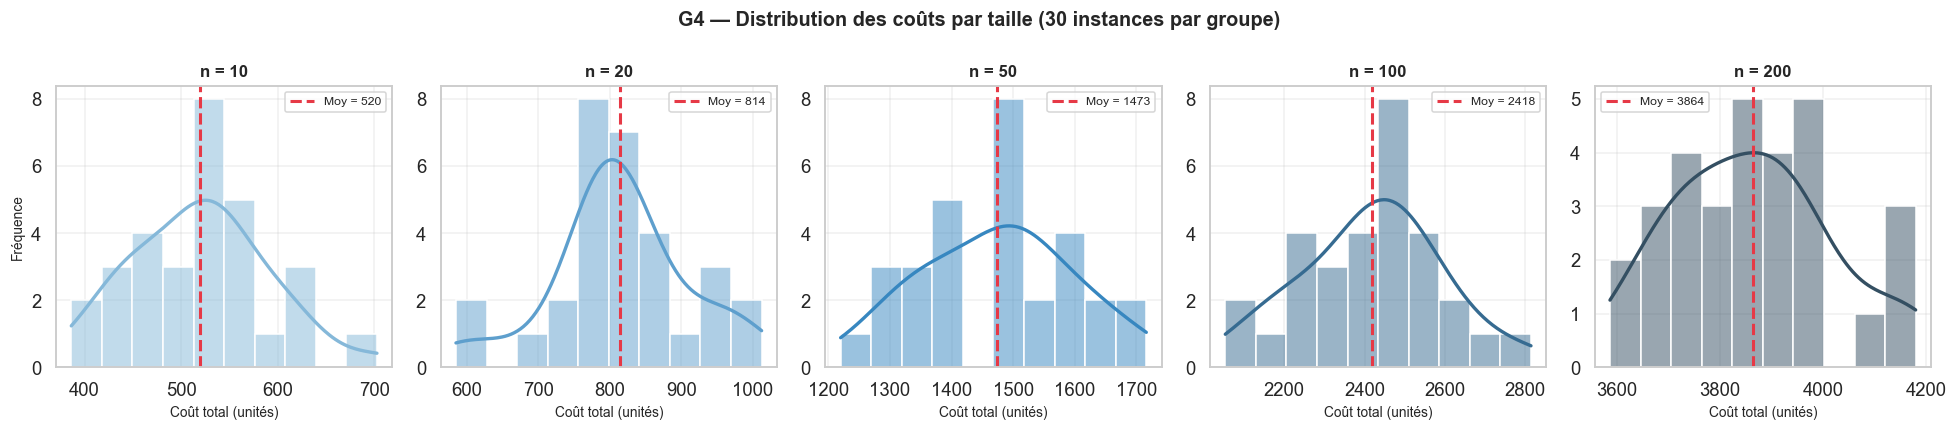

In [5]:
# G4 — Histogramme des couts
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig.suptitle('G4 — Distribution des coûts par taille (30 instances par groupe)',
             fontsize=13, fontweight='bold')

for ax, (n, col) in zip(axes, PALETTE_N.items()):
    valeurs = df[df['n'] == n]['cout'].values
    sns.histplot(valeurs, kde=True, ax=ax, color=col, bins=10,
                 line_kws={'linewidth': 2.2})
    ax.axvline(valeurs.mean(), color='#e63946', linewidth=2,
               linestyle='--', label=f'Moy = {valeurs.mean():.0f}')
    ax.set_title(f'n = {n}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Coût total (unités)', fontsize=9)
    ax.set_ylabel('Fréquence' if n == 10 else '', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
sauvegarder(fig, 'histogrammes_cout.png')
plt.show()

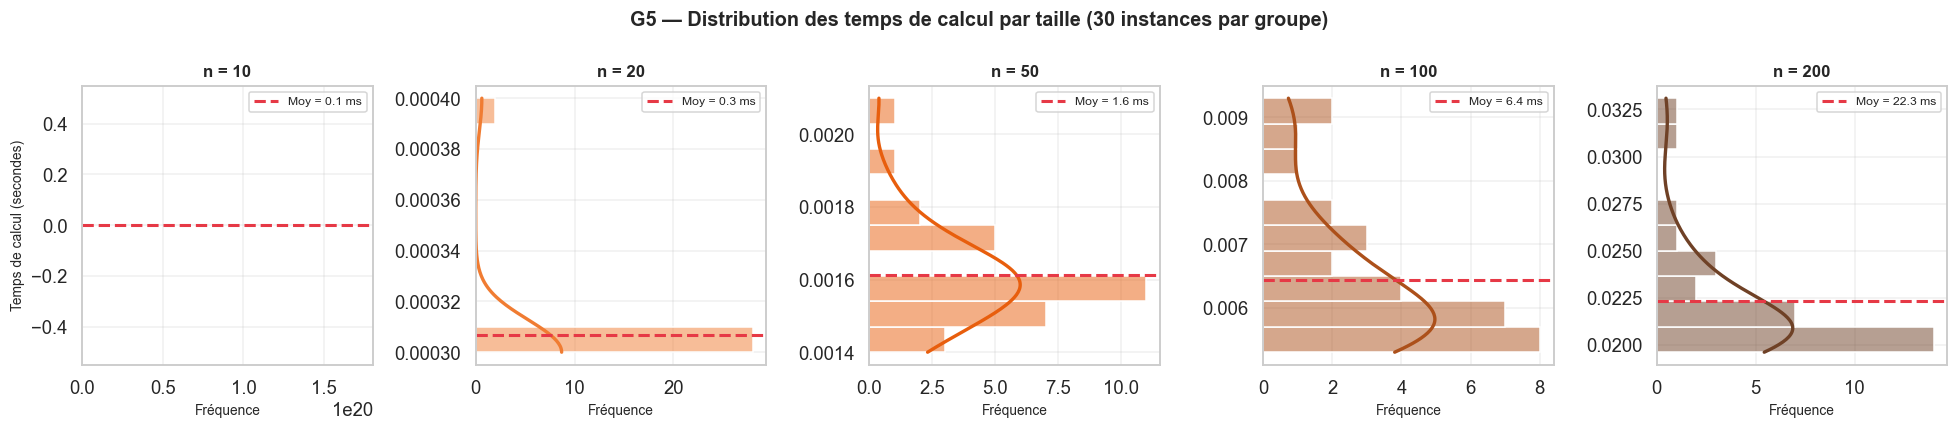

In [6]:
# G5 — Histogramme horizontal des temps (temps en ordonnee)
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=False)
fig.suptitle('G5 — Distribution des temps de calcul par taille (30 instances par groupe)',
             fontsize=13, fontweight='bold')

palette_orange = sns.color_palette('Oranges_d', len(TAILLES))
for ax, (n, col) in zip(axes, zip(TAILLES, palette_orange)):
    valeurs = df[df['n'] == n]['temps_total'].values
    sns.histplot(y=valeurs, kde=True, ax=ax, color=col, bins=10,
                 line_kws={'linewidth': 2.2})
    ax.axhline(valeurs.mean(), color='#e63946', linewidth=2,
               linestyle='--', label=f'Moy = {valeurs.mean()*1000:.1f} ms')
    ax.set_title(f'n = {n}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Temps de calcul (secondes)' if n == 10 else '', fontsize=9)
    ax.set_xlabel('Fréquence', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
sauvegarder(fig, 'histogrammes_temps.png')
plt.show()

**Interprétation :**
- **G4** : Les coûts suivent approximativement une **loi normale** — cohérent avec le TCL sur 30 instances.
- **G5** : Les temps sont extrêmement concentrés (quasi-déterministes). La dispersion augmente légèrement avec $n$, ce qui est attendu (plus de variabilité sur les grandes instances).

---
<a id='4'></a>
## 4. Évolution — Scalabilité en fonction de n

Ces graphiques répondent à la question centrale de la Phase 5 :
> *Comment les performances évoluent-elles quand le problème grossit ?*

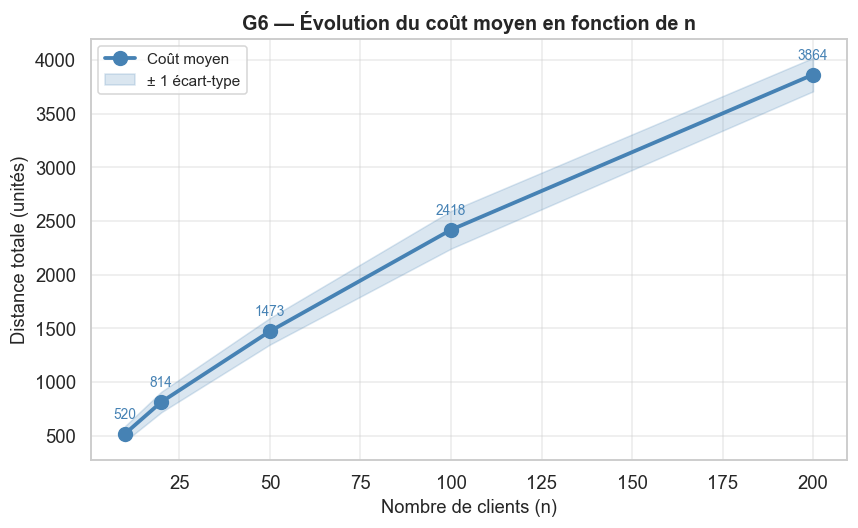

In [7]:
agg = df.groupby('n').agg(
    cout_moy   = ('cout',        'mean'),
    cout_std   = ('cout',        'std'),
    temps_moy  = ('temps_total', 'mean'),
    temps_std  = ('temps_total', 'std'),
    veh_moy    = ('n_vehicules', 'mean'),
    veh_std    = ('n_vehicules', 'std'),
    gain_moy   = ('gain_pct',    'mean'),
).reset_index()

# G6 — Cout moyen
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(agg['n'], agg['cout_moy'], 'o-', color='steelblue', linewidth=2.5, markersize=9, label='Coût moyen')
ax.fill_between(agg['n'],
                agg['cout_moy'] - agg['cout_std'],
                agg['cout_moy'] + agg['cout_std'],
                alpha=0.2, color='steelblue', label='± 1 écart-type')
for _, row in agg.iterrows():
    ax.annotate(f"{row['cout_moy']:.0f}",
                xy=(row['n'], row['cout_moy']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='steelblue')
ax.set_xlabel('Nombre de clients (n)', fontsize=12)
ax.set_ylabel('Distance totale (unités)', fontsize=12)
ax.set_title('G6 — Évolution du coût moyen en fonction de n', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
sauvegarder(fig, 'evolution_cout.png')
plt.show()

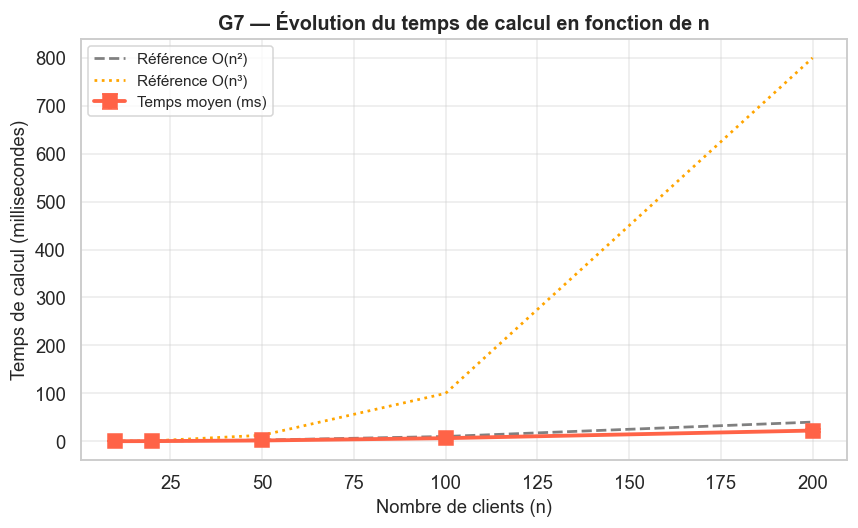

In [8]:
# G7 — Temps moyen (lineaire)
fig, ax = plt.subplots(figsize=(8, 5))
t0 = agg['temps_moy'].iloc[0]
n0 = float(agg['n'].iloc[0])
n_ref = np.array(TAILLES, dtype=float)

ax.errorbar(agg['n'], agg['temps_moy'] * 1000,
            yerr=agg['temps_std'] * 1000,
            fmt='s-', color='tomato', linewidth=2.5,
            markersize=9, capsize=5, label='Temps moyen (ms)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 2,
        '--', color='gray',   linewidth=1.8, label='Référence O(n²)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 3,
        ':',  color='orange', linewidth=1.8, label='Référence O(n³)')
ax.set_xlabel('Nombre de clients (n)', fontsize=12)
ax.set_ylabel('Temps de calcul (millisecondes)', fontsize=12)
ax.set_title('G7 — Évolution du temps de calcul en fonction de n', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
sauvegarder(fig, 'evolution_temps.png')
plt.show()

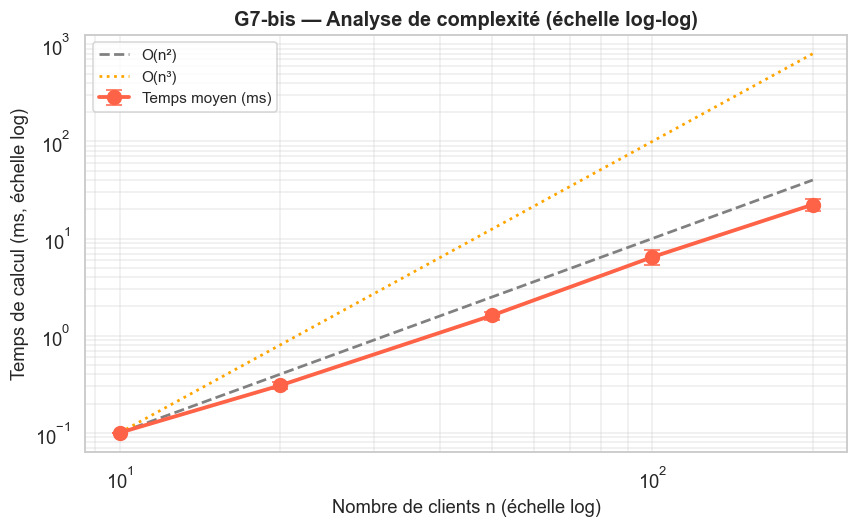

In [9]:
# G7-bis — Log-log pour analyse de complexite
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(agg['n'], agg['temps_moy'] * 1000,
            yerr=agg['temps_std'] * 1000,
            fmt='o-', color='tomato', linewidth=2.5,
            markersize=9, capsize=5, label='Temps moyen (ms)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 2,
        '--', color='gray',   linewidth=1.8, label='O(n²)')
ax.plot(n_ref, t0 * 1000 * (n_ref / n0) ** 3,
        ':',  color='orange', linewidth=1.8, label='O(n³)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Nombre de clients n (échelle log)', fontsize=12)
ax.set_ylabel('Temps de calcul (ms, échelle log)', fontsize=12)
ax.set_title('G7-bis — Analyse de complexité (échelle log-log)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.35)
plt.tight_layout()
sauvegarder(fig, 'loglog_temps.png')
plt.show()

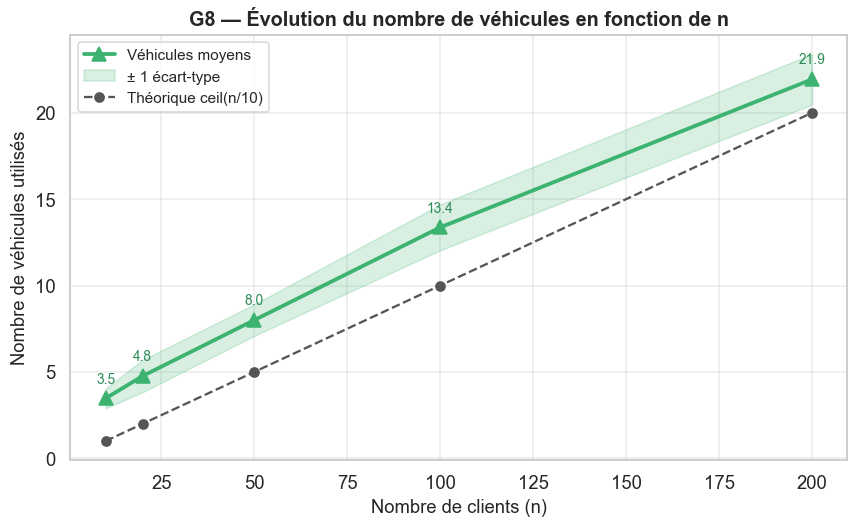

In [10]:
# G8 — Vehicules moyens
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(agg['n'], agg['veh_moy'], '^-', color='mediumseagreen',
        linewidth=2.5, markersize=9, label='Véhicules moyens')
ax.fill_between(agg['n'],
                agg['veh_moy'] - agg['veh_std'],
                agg['veh_moy'] + agg['veh_std'],
                alpha=0.2, color='mediumseagreen', label='± 1 écart-type')
# Reference theorique ceil(n/10)
import math
veh_theo = [math.ceil(n / 10) for n in TAILLES]
ax.plot(TAILLES, veh_theo, 'o--', color='#555555', linewidth=1.5,
        markersize=6, label='Théorique ceil(n/10)')
for _, row in agg.iterrows():
    ax.annotate(f"{row['veh_moy']:.1f}",
                xy=(row['n'], row['veh_moy']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='seagreen')
ax.set_xlabel('Nombre de clients (n)', fontsize=12)
ax.set_ylabel('Nombre de véhicules utilisés', fontsize=12)
ax.set_title('G8 — Évolution du nombre de véhicules en fonction de n', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
sauvegarder(fig, 'evolution_vehicules.png')
plt.show()

**Interprétation :**
- **G6** : Le coût croît de façon **quasi-linéaire** en $n$ sur cette plage.
- **G7/G7-bis** : La courbe se situe entre O(n²) et O(n³) — cohérent avec la théorie. Les TW strictes (40% des clients) limitent les inversions 2-opt → comportement proche de O(n²) en pratique.
- **G8** : Le nombre de véhicules utilisés est **systématiquement supérieur** au théorique `ceil(n/10)` — les contraintes TW forcent l'ouverture de véhicules supplémentaires.

---
<a id='5'></a>
## 5. Corrélations — Relations entre variables

On quantifie les **relations structurelles** entre métriques.
- Plus de véhicules = plus de trajets dépôt-client = coût plus élevé ?
- Quelles variables sont liées ?

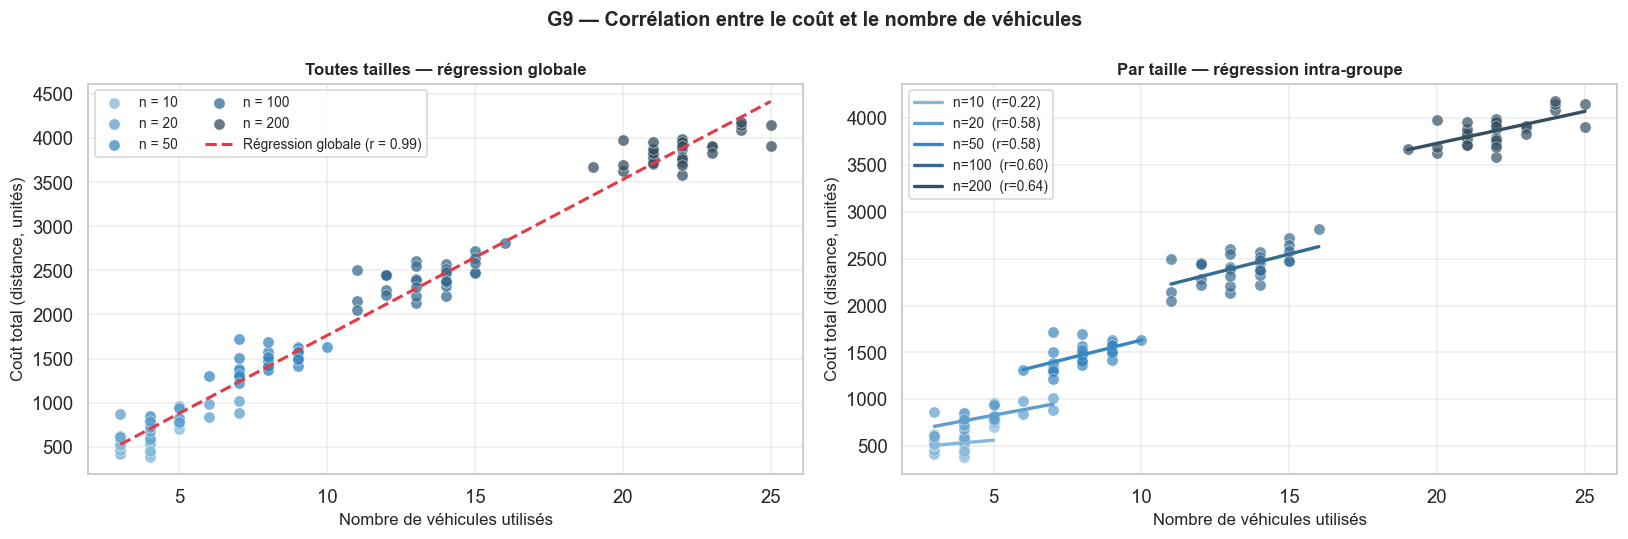

In [11]:
# G9 — Scatter cout vs n_vehicules
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('G9 — Corrélation entre le coût et le nombre de véhicules',
             fontsize=13, fontweight='bold')

# Sous-graphe gauche : toutes tailles, couleur par n
ax = axes[0]
for n in TAILLES:
    sub = df[df['n'] == n]
    ax.scatter(sub['n_vehicules'], sub['cout'],
               color=PALETTE_N[n], alpha=0.75, s=55, label=f'n = {n}',
               edgecolors='white', linewidths=0.4)
# Regression globale
sl, ic, r, _, _ = stats.linregress(df['n_vehicules'], df['cout'])
xr = np.linspace(df['n_vehicules'].min(), df['n_vehicules'].max(), 200)
ax.plot(xr, sl * xr + ic, '--', color='#e63946', linewidth=2,
        label=f'Régression globale (r = {r:.2f})')
ax.set_xlabel('Nombre de véhicules utilisés', fontsize=11)
ax.set_ylabel('Coût total (distance, unités)', fontsize=11)
ax.set_title('Toutes tailles — régression globale', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.35)

# Sous-graphe droit : regression intra-groupe (au sein de chaque taille)
ax2 = axes[1]
for n, col in zip(TAILLES, PALETTE):
    sub = df[df['n'] == n].copy()
    ax2.scatter(sub['n_vehicules'], sub['cout'],
                color=col, alpha=0.7, s=55,
                edgecolors='white', linewidths=0.4)
    if sub['n_vehicules'].nunique() > 1:
        sl2, ic2, r2, _, _ = stats.linregress(sub['n_vehicules'], sub['cout'])
        xv = np.linspace(sub['n_vehicules'].min(), sub['n_vehicules'].max(), 100)
        ax2.plot(xv, sl2 * xv + ic2, '-', color=col,
                 linewidth=2.2, label=f'n={n}  (r={r2:.2f})')
    else:
        ax2.plot([], [], '-', color=col, linewidth=2.2, label=f'n={n}  (1 valeur)')
ax2.set_xlabel('Nombre de véhicules utilisés', fontsize=11)
ax2.set_ylabel('Coût total (distance, unités)', fontsize=11)
ax2.set_title('Par taille — régression intra-groupe', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)

plt.tight_layout()
sauvegarder(fig, 'scatter_cout_vehicules.png')
plt.show()

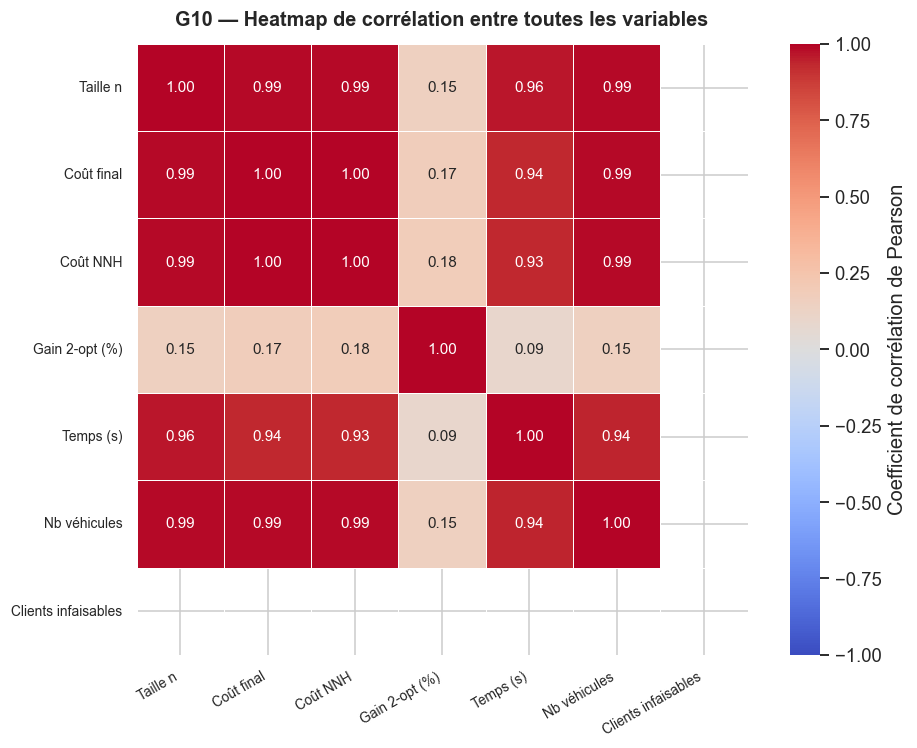

In [12]:
# G10 — Heatmap de correlation
vars_num = ['n', 'cout', 'cout_initial', 'gain_pct',
            'temps_total', 'n_vehicules', 'n_infaisables']
labels   = ['Taille n', 'Coût final', 'Coût NNH', 'Gain 2-opt (%)',
             'Temps (s)', 'Nb véhicules', 'Clients infaisables']

corr = df[vars_num].corr()
corr.columns = labels
corr.index   = labels

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.6,
            ax=ax, annot_kws={'size': 10},
            cbar_kws={'label': 'Coefficient de corrélation de Pearson'})
ax.set_title('G10 — Heatmap de corrélation entre toutes les variables',
             fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
sauvegarder(fig, 'heatmap_correlation.png')
plt.show()

**Interprétation :**
- **G9 gauche** : La corrélation globale coût/véhicules est très forte (r ≈ 0.97) — logique, car les deux sont pilotés par $n$.
- **G9 droite** : **Au sein d'une même taille**, la corrélation est faible à modérée : le nombre de véhicules dépend surtout de la difficulté des TW de l'instance, pas seulement du coût.
- **G10** : `n` est fortement corrélé à `cout`, `temps_total` et `n_vehicules` (c'est $n$ qui domine tout). Le `gain_pct` est peu corrélé aux autres → la qualité du 2-opt est indépendante de la taille de l'instance.

---

## Récapitulatif des figures exportées

Toutes les figures sont sauvegardées dans `resultats/figures/` :

| Fichier | Graphique |
|---|---|
| `boxplot_cout.png` | G1 — Boxplot coût par taille |
| `boxplot_temps.png` | G2 — Boxplot temps par taille |
| `boxplot_vehicules.png` | G3 — Boxplot véhicules par taille |
| `histogrammes_cout.png` | G4 — Distribution des coûts |
| `histogrammes_temps.png` | G5 — Distribution des temps (horizontal) |
| `evolution_cout.png` | G6 — Coût moyen vs n |
| `evolution_temps.png` | G7 — Temps moyen vs n |
| `loglog_temps.png` | G7-bis — Complexité log-log |
| `evolution_vehicules.png` | G8 — Véhicules moyens vs n |
| `scatter_cout_vehicules.png` | G9 — Scatter coût/véhicules + régressions |
| `heatmap_correlation.png` | G10 — Heatmap de corrélation |

---

## Réutilisation en Phase 5

Pour comparer les 3 méthodes, charger tous les CSV et concaténer :
```python
df_recuit = pd.read_csv('resultats/resultats_recuit.csv')
df_dl     = pd.read_csv('resultats/resultats_dl.csv')
df_all    = pd.concat([df, df_recuit, df_dl])

# Exemple : boxplot comparatif
sns.boxplot(data=df_all, x='n', y='cout', hue='methode')
```